# 01_EDA: Exploratory Data Analysis for Azure VM CPU Utilization

This notebook performs exploratory data analysis for the filtered long-running Microsoft Azure VM trace used in the capstone project. The analysis focuses on hourly CPU utilization for 2,000 sampled VMs over 720 hours.

**Purpose of this EDA**
- Validate dataset completeness and structure.
- Summarize CPU utilization patterns across VMs and time.
- Identify seasonality, burstiness, idle behavior, and overprovisioning indicators.
- Generate figures and summary tables that support feature engineering, model selection, anomaly detection, clustering, and right-sizing decisions.

**Important scope note:** This study uses CPU utilization only. Memory, disk, storage, and network metrics are not included because reliable public VM-level datasets with aligned metrics are not available for this trace.

In [2]:
# Core libraries
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# Default plot size
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load the Hourly Dataset

Expected input file:

`data/processed/hourly_n2000.parquet`

If the notebook is run from the project root, the path below should work directly. Update `DATA_PATH` if the file is stored elsewhere.

In [3]:
DATA_PATH = '../data/processed/hourly_n2000.parquet'

if not os.path.exists(DATA_PATH):
    alt_path = 'data/processed/hourly_n2000.parquet'
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

print(f'Using data path: {DATA_PATH}')

df = pd.read_parquet(DATA_PATH)
print('Shape:', df.shape)
df.head()

Using data path: ../data/processed/hourly_n2000.parquet
Shape: (1440000, 10)


,vm_id,hour_index,avg_cpu_mean,avg_cpu_min,avg_cpu_max,avg_cpu_std,readings_count,hour_of_day,day_index,day_of_cycle
0,0,0,1.467899,1.281514,1.953717,0.199937,12,0,0,0
1,0,1,1.555141,1.382086,2.036626,0.167614,12,1,0,0
2,0,2,1.683001,1.511600,2.219195,0.220013,12,2,0,0
3,0,3,1.752279,1.615813,2.279033,0.176076,12,3,0,0
4,0,4,1.926054,1.774914,2.230747,0.127170,12,4,0,0


## 2. Basic Structure and Data Quality Checks

This section verifies that the dataset contains the expected number of VMs, hourly observations, and valid CPU utilization values.

In [4]:
print('Columns:')
print(df.columns.tolist())

print('Data types:')
print(df.dtypes)

print('Missing values:')
print(df.isna().sum())

print('Duplicate VM-hour rows:', df.duplicated(subset=['vm_id', 'hour_index']).sum())

print('Expected rows for 2,000 VMs x 720 hours:', 2000 * 720)
print('Actual rows:', len(df))
print('Unique VMs:', df['vm_id'].nunique())
print('Unique hours:', df['hour_index'].nunique())

Columns:
['vm_id', 'hour_index', 'avg_cpu_mean', 'avg_cpu_min', 'avg_cpu_max', 'avg_cpu_std', 'readings_count', 'hour_of_day', 'day_index', 'day_of_cycle']
Data types:
vm_id               int32
hour_index          int16
avg_cpu_mean      float32
avg_cpu_min       float32
avg_cpu_max       float32
avg_cpu_std       float32
readings_count      int64
hour_of_day          int8
day_index            int8
day_of_cycle         int8
dtype: object
Missing values:
vm_id             0
hour_index        0
avg_cpu_mean      0
avg_cpu_min       0
avg_cpu_max       0
avg_cpu_std       0
readings_count    0
hour_of_day       0
day_index         0
day_of_cycle      0
dtype: int64
Duplicate VM-hour rows: 0
Expected rows for 2,000 VMs x 720 hours: 1440000
Actual rows: 1440000
Unique VMs: 2000
Unique hours: 720


In [5]:
# Completeness check: each VM should have 720 hourly observations
hours_per_vm = df.groupby('vm_id')['hour_index'].nunique()
summary_hours = hours_per_vm.describe()
summary_hours

count    2000.0
mean      720.0
std         0.0
min       720.0
25%       720.0
50%       720.0
75%       720.0
max       720.0
Name: hour_index, dtype: float64

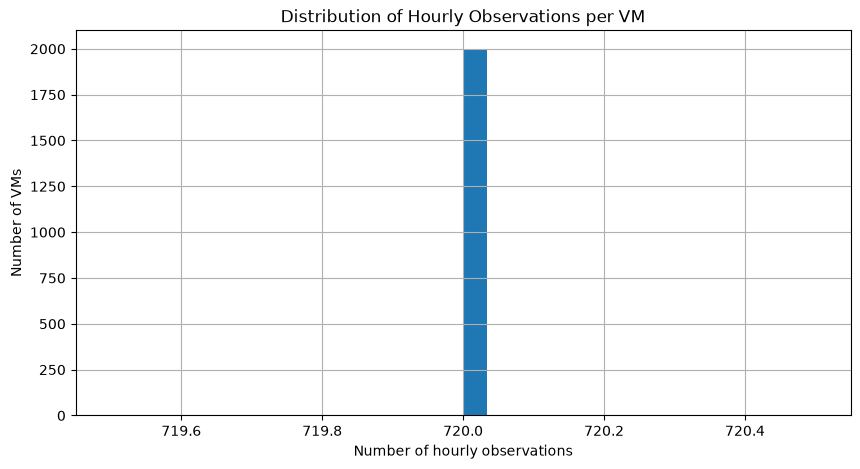

In [6]:
plt.figure()
hours_per_vm.hist(bins=30)
plt.title('Distribution of Hourly Observations per VM')
plt.xlabel('Number of hourly observations')
plt.ylabel('Number of VMs')
plt.show()

**Interpretation guidance:** A single spike at 720 confirms complete time series for all sampled VMs. This supports consistent forecasting and anomaly detection across equal-length VM histories.

## 3. CPU Utilization Summary Statistics

This section summarizes hourly mean, minimum, maximum, and standard deviation of CPU utilization.

In [7]:
cpu_cols = ['avg_cpu_mean', 'avg_cpu_min', 'avg_cpu_max', 'avg_cpu_std']
summary = df[cpu_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
avg_cpu_mean,1440000.0,6.733663,11.906579,0.002586,0.072818,0.282035,1.612328,3.579473,6.538005,23.761404,73.827329,99.584106
avg_cpu_min,1440000.0,5.561836,10.777894,0.002416,0.056650,0.211956,1.186584,2.854103,5.406034,19.064022,62.982798,99.445190
avg_cpu_max,1440000.0,9.734010,14.277997,0.002643,0.090197,0.460630,2.562699,5.550821,9.850277,35.717255,88.496315,100.000000
avg_cpu_std,1440000.0,1.279247,2.752648,0.000022,0.003583,0.029340,0.216014,0.551327,1.108769,5.077229,12.233341,48.836868


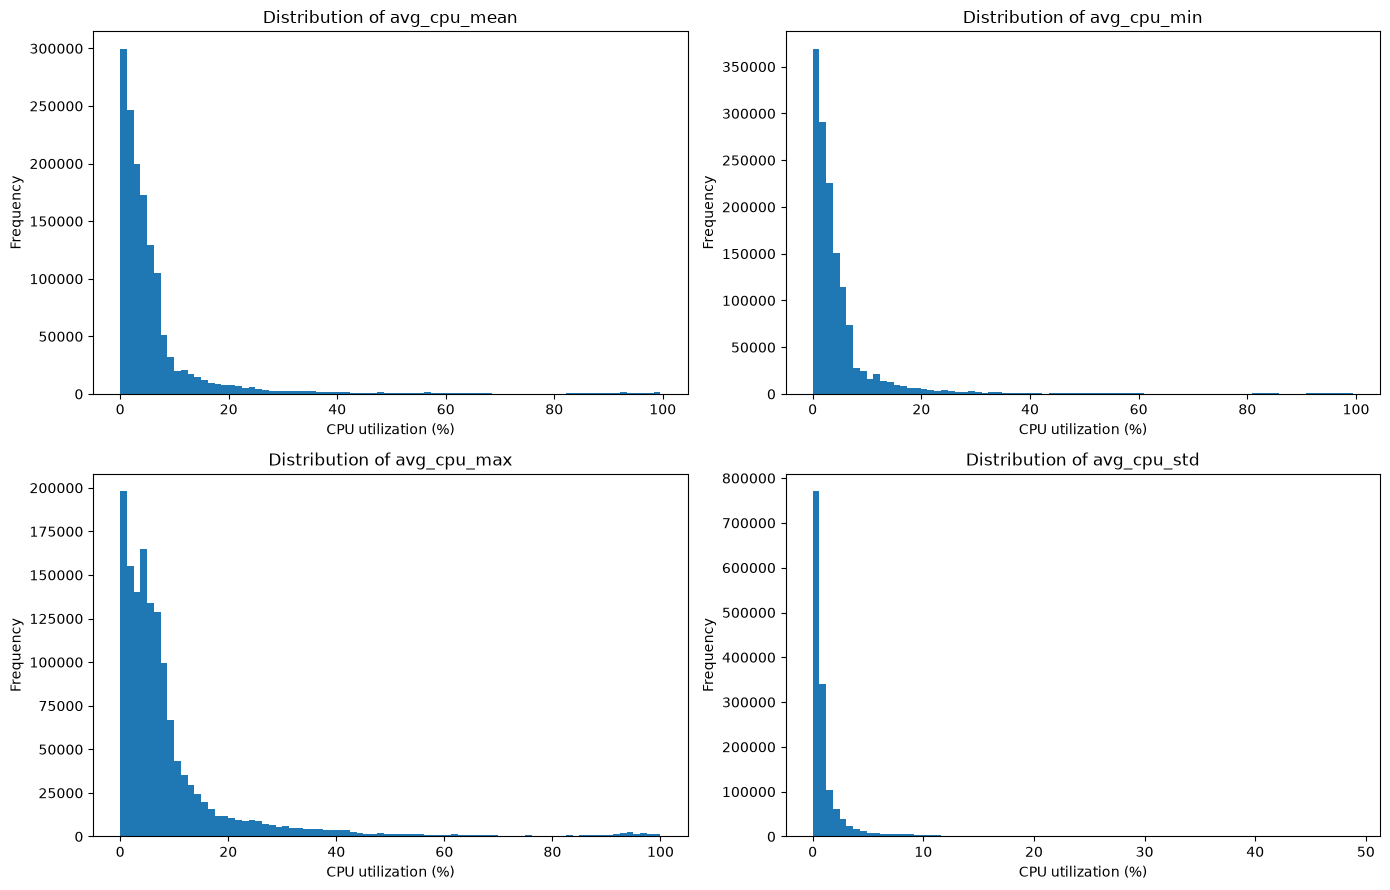

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, cpu_cols):
    ax.hist(df[col].dropna(), bins=80)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('CPU utilization (%)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation guidance:** Highly right-skewed CPU utilization supports the need for robust forecasting metrics and workload segmentation. It also motivates right-sizing analysis because many VMs may operate at consistently low utilization.

## 4. VM-Level Utilization Profiles

This section aggregates hourly observations to VM-level summaries. These summaries help identify idle, steady, bursty, and high-utilization workloads.

In [42]:
vm_summary = df.groupby('vm_id').agg(
    mean_cpu=('avg_cpu_mean', 'mean'),
    median_cpu=('avg_cpu_mean', 'median'),
    p95_cpu_mean=('avg_cpu_mean', lambda x: np.percentile(x, 95)),
    p95_cpu_max=('avg_cpu_max', lambda x: np.percentile(x, 95)),
    max_cpu=('avg_cpu_max', 'max'),
    min_cpu=('avg_cpu_min', 'min'),
    std_cpu=('avg_cpu_mean', 'std'),
    mean_hourly_std=('avg_cpu_std', 'mean')
).reset_index()

vm_summary['burstiness_index'] = vm_summary['p95_cpu_mean'] / (vm_summary['mean_cpu'] + 1e-6)
vm_summary.head()

,vm_id,mean_cpu,median_cpu,p95_cpu_mean,p95_cpu_max,max_cpu,min_cpu,std_cpu,mean_hourly_std,burstiness_index
0,0,1.279185,0.949102,2.944079,3.421977,37.834385,0.393511,0.928989,0.156047,2.301527
1,1,4.758062,4.622718,5.482380,13.374448,74.709747,2.604533,1.480785,1.404490,1.152229
2,2,2.646828,2.231540,3.432912,7.234301,91.568214,1.670889,2.089144,0.599331,1.296991
3,3,0.417827,0.402262,0.543828,1.824460,5.041344,0.153870,0.081224,0.215191,1.301559
4,4,41.188538,41.084167,41.506248,41.896080,100.000000,38.693241,0.889003,0.687072,1.007714


In [43]:
vm_summary.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, .998]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.8%,max
vm_id,2000.0,999.500000,577.494589,0.000000,19.990000,99.950000,499.750000,999.500000,1499.250000,1899.050000,1979.010000,1995.002000,1999.000000
mean_cpu,2000.0,6.733663,10.915565,0.003261,0.103872,0.361241,1.804644,3.922609,6.903323,22.536865,61.719056,94.164184,98.751381
median_cpu,2000.0,6.269875,11.170345,0.003171,0.077156,0.261854,1.606529,3.495149,6.320401,20.809251,66.371318,95.807389,98.961838
p95_cpu_mean,2000.0,10.257446,15.635409,0.003514,0.133324,0.480434,2.506642,5.084095,9.400672,41.272179,90.926223,96.870601,99.381531
p95_cpu_max,2000.0,17.092060,18.901114,0.003688,0.348372,1.252659,5.761868,10.736207,18.475423,57.404980,94.294730,99.227713,100.000000
max_cpu,2000.0,59.454491,32.457932,0.004506,2.087980,6.931074,29.050596,63.015545,92.482300,98.775159,99.398329,100.000000,100.000000
min_cpu,2000.0,2.926413,5.941423,0.002416,0.041771,0.151266,0.730319,1.759187,3.339022,8.253654,19.724909,76.381228,94.304161
std_cpu,2000.0,2.565570,4.016718,0.000090,0.023505,0.079851,0.392001,1.172030,3.017089,9.592026,20.657580,32.133927,36.044888
mean_hourly_std,2000.0,1.279247,1.742986,0.000077,0.026034,0.103366,0.402741,0.854753,1.316125,4.363888,8.968494,13.898448,19.553148
burstiness_index,2000.0,1.522836,0.835419,0.570146,1.008852,1.055425,1.131069,1.235772,1.546714,3.034400,4.977487,7.295630,13.688424


### Outlier detection

In [44]:
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (series < lower) | (series > upper)

vm_summary['max_cpu_outlier'] = find_iqr_outliers(vm_summary['max_cpu'])

outlier_vms = vm_summary[vm_summary['max_cpu_outlier']
]

print(f"Outlier VMs: {len(outlier_vms)}")
outlier_vms[['vm_id', 'max_cpu']]

Outlier VMs: 0


,vm_id,max_cpu


In [45]:
vm_summary[['p95_cpu_mean','p95_cpu_max','max_cpu']].describe(percentiles=[0.01, 0.998]).T

,count,mean,std,min,1%,99.8%,max
p95_cpu_mean,2000.0,10.257446,15.635409,0.003514,0.133324,96.870601,99.381531
p95_cpu_max,2000.0,17.092060,18.901114,0.003688,0.348372,99.227713,100.000000
max_cpu,2000.0,59.454491,32.457932,0.004506,2.087980,100.000000,100.000000


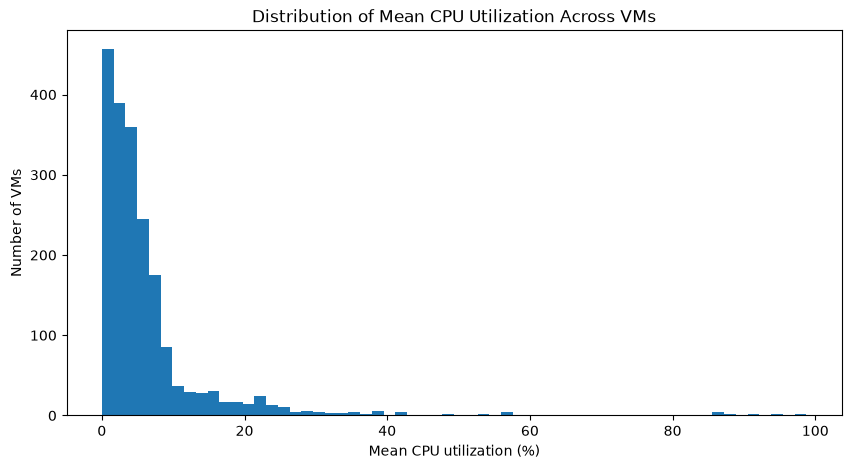

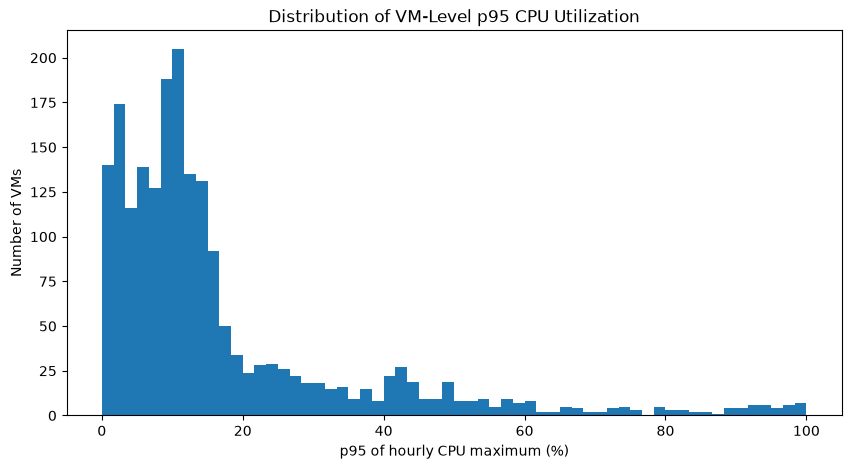

In [15]:
plt.figure()
plt.hist(vm_summary['mean_cpu'], bins=60)
plt.title('Distribution of Mean CPU Utilization Across VMs')
plt.xlabel('Mean CPU utilization (%)')
plt.ylabel('Number of VMs')
plt.show()

plt.figure()
plt.hist(vm_summary['p95_cpu_max'], bins=60)
plt.title('Distribution of VM-Level p95 CPU Utilization')
plt.xlabel('p95 of hourly CPU maximum (%)')
plt.ylabel('Number of VMs')
plt.show()

**Interpretation guidance:** The VM-level mean CPU distribution supports RQ4 by showing whether sustained underutilization is common. The p95 distribution is especially relevant because p95 CPU is used as a practical right-sizing indicator.

## 5. Preliminary Overprovisioning Indicator

For interim analysis, a VM is flagged as potentially overprovisioned if its lifetime p95 CPU utilization is below 40%. This is a CPU-only indicator and should not be treated as a complete production rightsizing recommendation because memory, network, disk, and application constraints are not available.

In [16]:
P95_THRESHOLD = 40
vm_summary['potentially_overprovisioned_cpu_only'] = vm_summary['p95_cpu_max'] < P95_THRESHOLD

overprov_rate = vm_summary['potentially_overprovisioned_cpu_only'].mean()
print(f'CPU-only potential overprovisioning rate: {overprov_rate:.2%}')

vm_summary['potentially_overprovisioned_cpu_only'].value_counts().rename(index={True: 'p95 CPU < 40%', False: 'p95 CPU >= 40%'})

CPU-only potential overprovisioning rate: 87.95%


potentially_overprovisioned_cpu_only
p95 CPU < 40%     1759
p95 CPU >= 40%     241
Name: count, dtype: int64

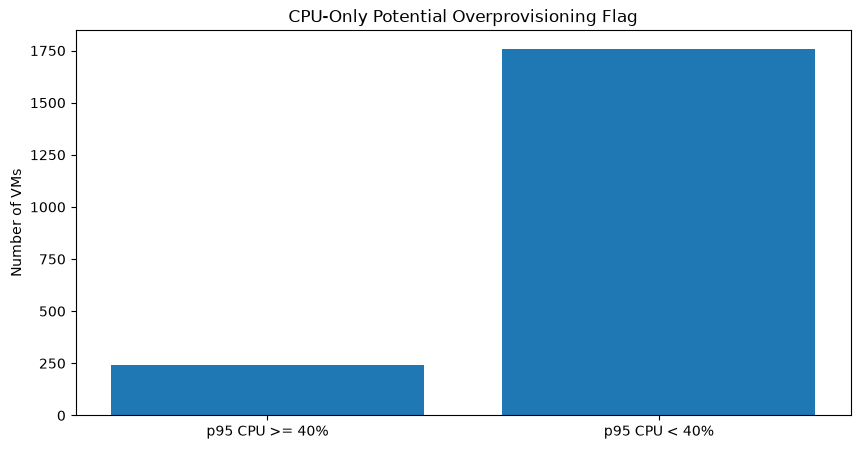

In [17]:
counts = vm_summary['potentially_overprovisioned_cpu_only'].value_counts().sort_index()
labels = ['p95 CPU >= 40%', 'p95 CPU < 40%']

plt.figure()
plt.bar(labels, counts.values)
plt.title('CPU-Only Potential Overprovisioning Flag')
plt.ylabel('Number of VMs')
plt.show()

**Interpretation guidance:** This chart provides preliminary evidence for RQ4. The result should be described as a CPU-only right-sizing signal, not a final resizing decision.

## 6. Temporal Patterns and Seasonality

This section examines utilization by hour of day and day of cycle. Since timestamps are relative and not calendar anchored, these should be interpreted as recurring cycle positions rather than actual weekdays or dates.

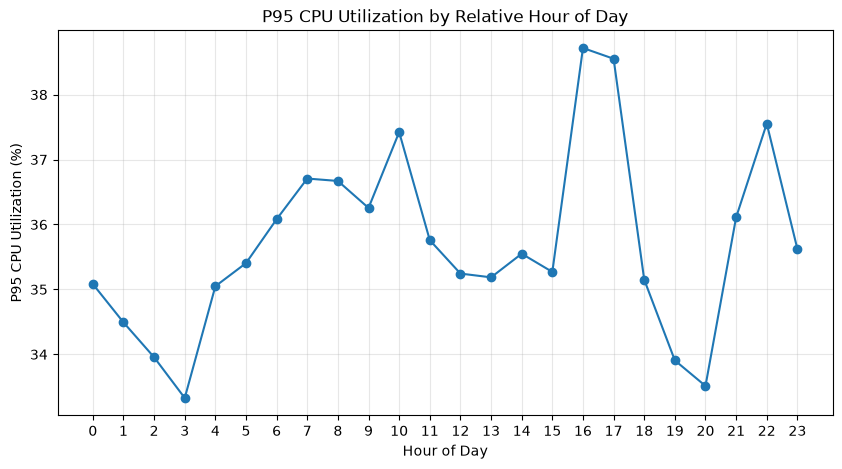

In [18]:
hourly_pattern = df.groupby('hour_of_day')['avg_cpu_max'].quantile(0.95)
plt.figure()
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('P95 CPU Utilization by Relative Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('P95 CPU Utilization (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

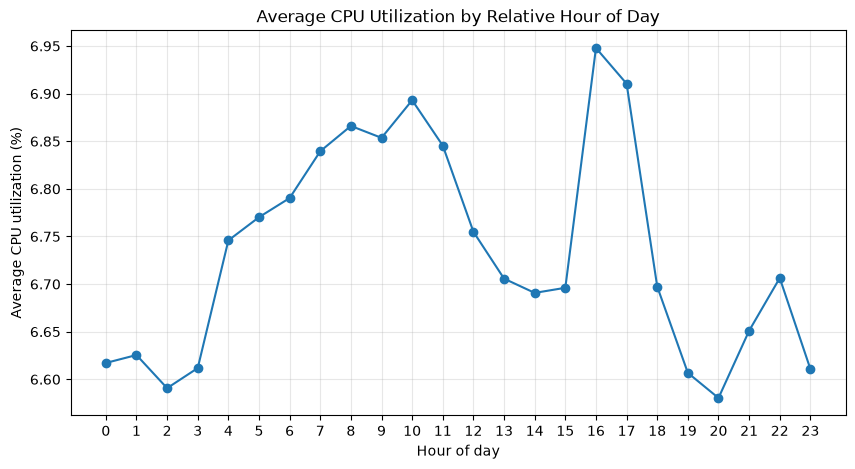

In [19]:
hourly_pattern = df.groupby('hour_of_day')['avg_cpu_mean'].mean()

plt.figure()
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Average CPU Utilization by Relative Hour of Day')
plt.xlabel('Hour of day')
plt.ylabel('Average CPU utilization (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

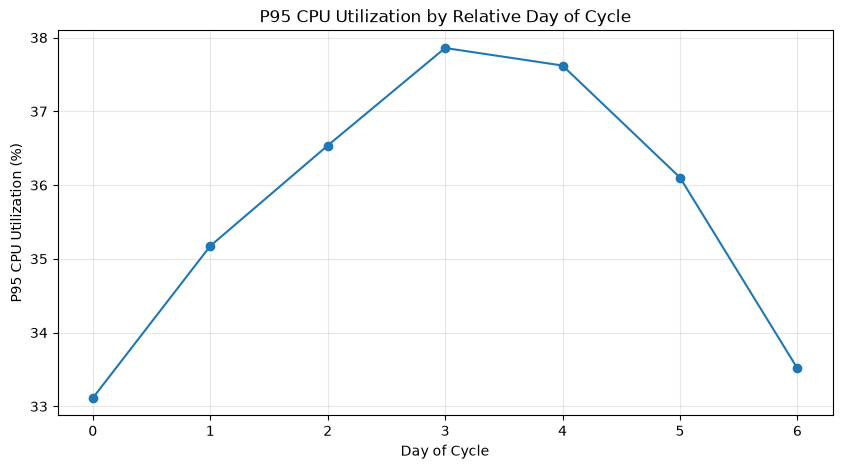

In [20]:
if 'day_of_cycle' in df.columns:
    cycle_pattern = df.groupby('day_of_cycle')['avg_cpu_max'].quantile(0.95)
    plt.figure()
    plt.plot(cycle_pattern.index, cycle_pattern.values, marker='o')
    plt.title('P95 CPU Utilization by Relative Day of Cycle')
    plt.xlabel('Day of Cycle')
    plt.ylabel('P95 CPU Utilization (%)')
    plt.xticks(sorted(df['day_of_cycle'].unique()))
    plt.grid(True, alpha=0.3)
    plt.show()

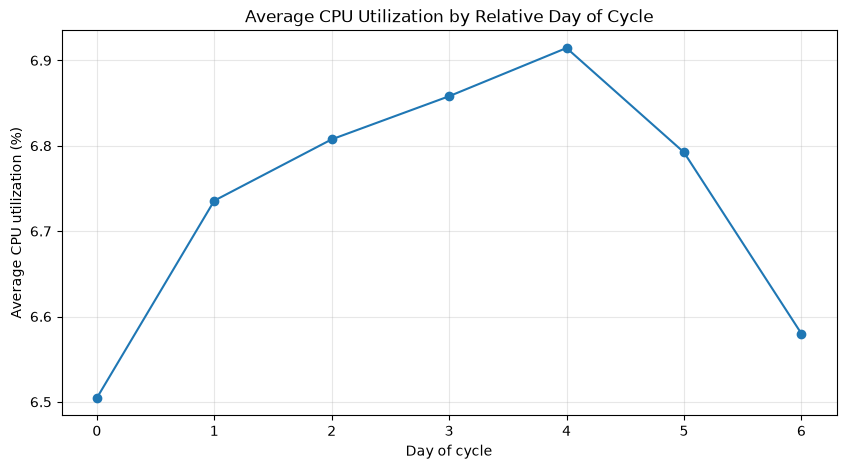

In [21]:
if 'day_of_cycle' in df.columns:
    cycle_pattern = df.groupby('day_of_cycle')['avg_cpu_mean'].mean()
    plt.figure()
    plt.plot(cycle_pattern.index, cycle_pattern.values, marker='o')
    plt.title('Average CPU Utilization by Relative Day of Cycle')
    plt.xlabel('Day of cycle')
    plt.ylabel('Average CPU utilization (%)')
    plt.xticks(sorted(df['day_of_cycle'].unique()))
    plt.grid(True, alpha=0.3)
    plt.show()

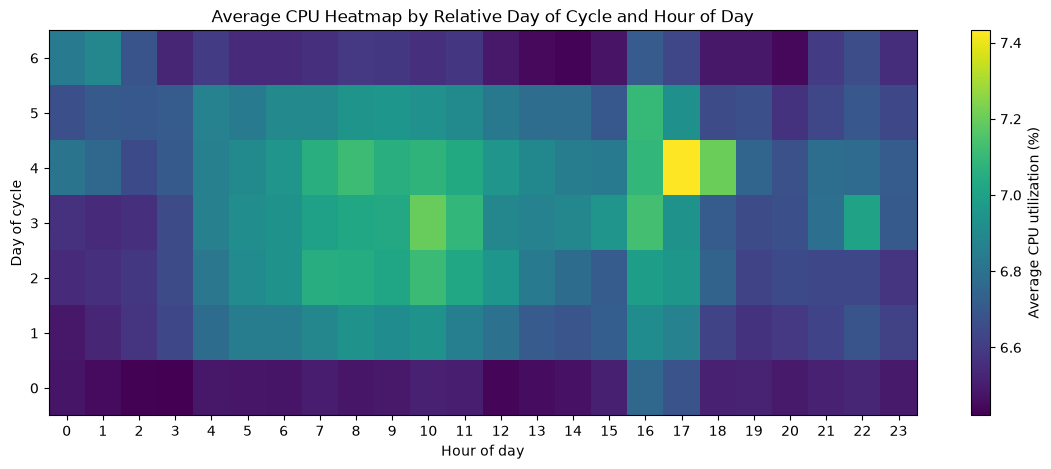

In [22]:
heatmap_data = df.pivot_table(
    index='day_of_cycle',
    columns='hour_of_day',
    values='avg_cpu_mean',
    aggfunc='mean'
)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data, aspect='auto', origin='lower')
plt.colorbar(label='Average CPU utilization (%)')
plt.title('Average CPU Heatmap by Relative Day of Cycle and Hour of Day')
plt.xlabel('Hour of day')
plt.ylabel('Day of cycle')
plt.xticks(range(24))
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.show()

**Interpretation guidance:** Recurring daily or weekly-cycle patterns justify lag features such as lag-24 and lag-168, as well as cyclical encodings for hour and day positions.

## 7. Representative VM Time-Series Examples

This section plots example VMs from different utilization profiles. These examples help explain why workload archetypes are useful.

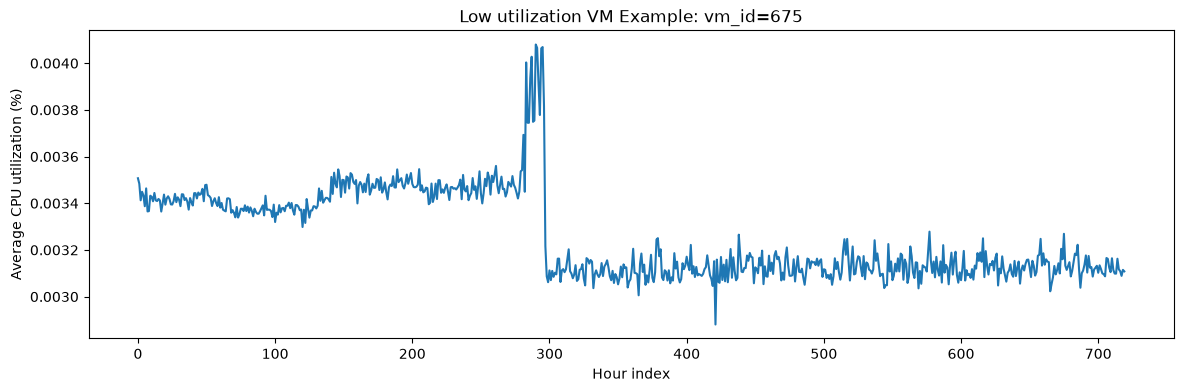

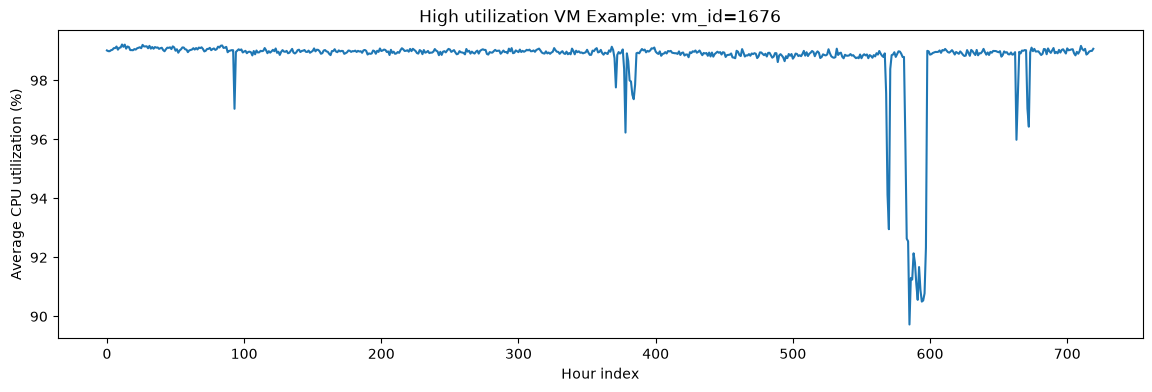

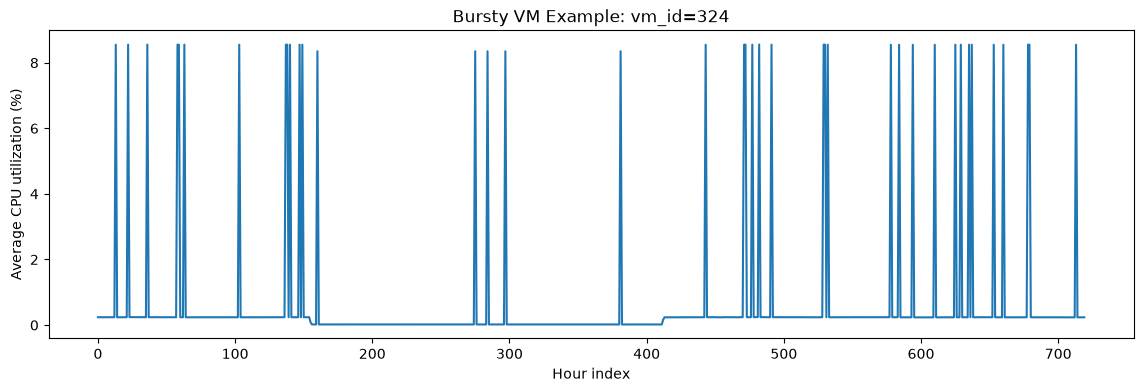

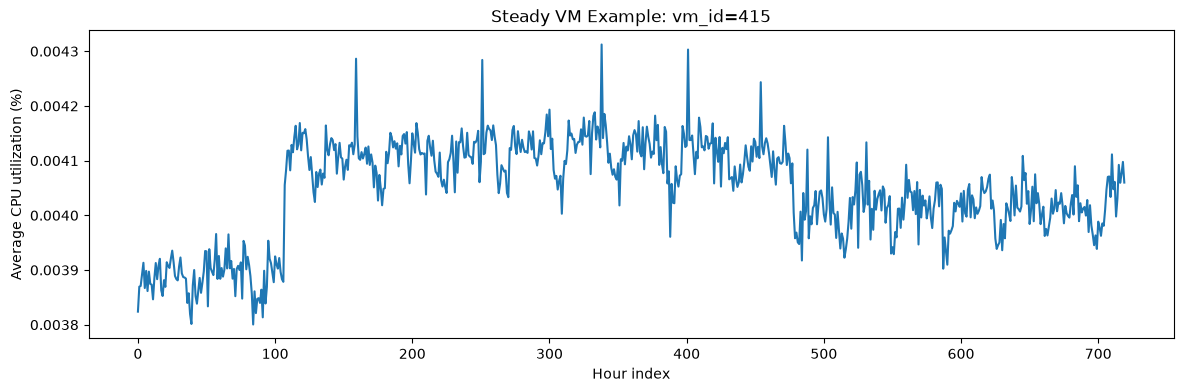

In [23]:
# Select representative examples
low_vm = vm_summary.sort_values('mean_cpu').iloc[0]['vm_id']
high_vm = vm_summary.sort_values('mean_cpu', ascending=False).iloc[0]['vm_id']
bursty_vm = vm_summary.sort_values('burstiness_index', ascending=False).iloc[0]['vm_id']
steady_vm = vm_summary.sort_values('std_cpu').iloc[0]['vm_id']

example_vms = {
    'Low utilization': low_vm,
    'High utilization': high_vm,
    'Bursty': bursty_vm,
    'Steady': steady_vm
}

for label, vm in example_vms.items():
    temp = df[df['vm_id'] == vm].sort_values('hour_index')
    plt.figure(figsize=(14, 4))
    plt.plot(temp['hour_index'], temp['avg_cpu_mean'])
    plt.title(f'{label} VM Example: vm_id={vm}')
    plt.xlabel('Hour index')
    plt.ylabel('Average CPU utilization (%)')
    plt.show()

**Interpretation guidance:** These sample traces can be used in the report to illustrate steady, bursty, idle, and high-utilization patterns. They support workload characterization in RQ3 and model comparison by archetype in RQ1.

## 8. Correlation Analysis

This section checks relationships among CPU summary variables. Correlation patterns help determine whether features are redundant or useful for model development.

                avg_cpu_mean  avg_cpu_min  avg_cpu_max  avg_cpu_std  readings_count   hour_of_day     day_index  \
avg_cpu_mean        1.000000     0.970295     0.915252     0.319933        0.000151 -3.107751e-04  8.283704e-03   
avg_cpu_min         0.970295     1.000000     0.831834     0.121196       -0.000032 -3.675660e-03  9.343852e-03   
avg_cpu_max         0.915252     0.831834     1.000000     0.641085        0.002157  6.039353e-03 -2.217095e-03   
avg_cpu_std         0.319933     0.121196     0.641085     1.000000        0.002520  1.573461e-02 -1.383844e-02   
readings_count      0.000151    -0.000032     0.002157     0.002520        1.000000  5.430210e-04  2.265813e-04   
hour_of_day        -0.000311    -0.003676     0.006039     0.015735        0.000543  1.000000e+00  2.401501e-19   
day_index           0.008284     0.009344    -0.002217    -0.013838        0.000227  2.401501e-19  1.000000e+00   
day_of_cycle        0.003398     0.001581     0.003683     0.006178       -0.001

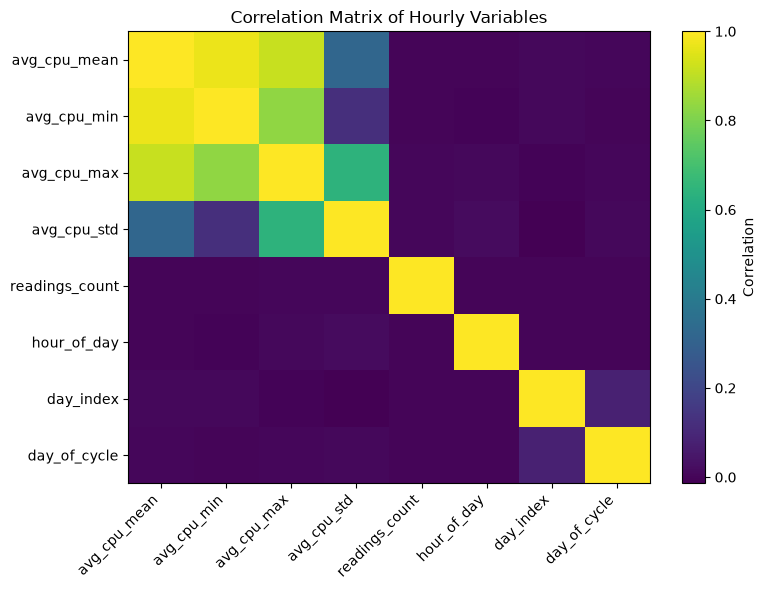

In [24]:
corr_cols = ['avg_cpu_mean', 'avg_cpu_min', 'avg_cpu_max', 'avg_cpu_std', 'readings_count', 'hour_of_day', 'day_index', 'day_of_cycle']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr(numeric_only=True)
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix of Hourly Variables')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

## 9. EDA Insight Summary for Report

This table converts EDA findings into modeling decisions that can be inserted into the interim/final report.

In [25]:
eda_summary = pd.DataFrame([
    {
        'EDA Finding': 'Complete 720-hour series per VM',
        'Why it matters': 'Supports consistent time-series modelling and fair model comparison',
        'Modeling decision': 'Use fixed train/validation/test splits across all VMs'
    },
    {
        'EDA Finding': 'CPU utilization is right-skewed across VMs',
        'Why it matters': 'Many VMs show low sustained utilization while a smaller subset has higher or burstier demand',
        'Modeling decision': 'Retain right-sizing analysis and evaluate performance by workload archetype'
    },
    {
        'EDA Finding': 'Daily or cycle-based temporal patterns may exist',
        'Why it matters': 'Forecasting models need features that capture recurring workload behavior',
        'Modeling decision': 'Include lag-24, lag-168, rolling statistics, and cyclical encodings'
    },
    {
        'EDA Finding': 'Representative VMs show idle, steady, bursty, and high-utilization behavior',
        'Why it matters': 'Single global model may perform differently by workload type',
        'Modeling decision': 'Use clustering to define workload archetypes and compare model performance by group'
    },
    {
        'EDA Finding': 'CPU-only p95 can flag potential overprovisioning',
        'Why it matters': 'Provides an interpretable FinOps signal but is not a complete production resizing decision',
        'Modeling decision': 'Use p95 CPU threshold as transparent right-sizing baseline and state CPU-only limitation'
    }
])

eda_summary

,EDA Finding,Why it matters,Modeling decision
0,Complete 720-hour series per VM,Supports consistent time-series modelling and ...,Use fixed train/validation/test splits across ...
1,CPU utilization is right-skewed across VMs,Many VMs show low sustained utilization while ...,Retain right-sizing analysis and evaluate perf...
2,Daily or cycle-based temporal patterns may exist,Forecasting models need features that capture ...,"Include lag-24, lag-168, rolling statistics, a..."
3,"Representative VMs show idle, steady, bursty, ...",Single global model may perform differently by...,Use clustering to define workload archetypes a...
4,CPU-only p95 can flag potential overprovisioning,Provides an interpretable FinOps signal but is...,Use p95 CPU threshold as transparent right-siz...


## 10. Save EDA Outputs

This section saves VM-level summary statistics and the EDA insight table for use in the report.

In [26]:
OUTPUT_DIR = '../data/reports'
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = 'data/reports'
os.makedirs(OUTPUT_DIR, exist_ok=True)

vm_summary.to_csv(os.path.join(OUTPUT_DIR, 'eda_vm_summary.csv'), index=False)
eda_summary.to_csv(os.path.join(OUTPUT_DIR, 'eda_insight_summary.csv'), index=False)

print('Saved:')
print(os.path.join(OUTPUT_DIR, 'eda_vm_summary.csv'))
print(os.path.join(OUTPUT_DIR, 'eda_insight_summary.csv'))

Saved:
../data/reports\eda_vm_summary.csv
../data/reports\eda_insight_summary.csv


### EDA Write-Up

Exploratory data analysis was conducted on the hourly dataset containing 1,440,000 observations from 2,000 long-running VMs over 720 hours. Initial data-quality checks confirmed that each VM contains a complete hourly time series, supporting consistent forecasting, anomaly detection, and workload characterization. CPU utilization was highly right-skewed, with many VMs operating at relatively low average utilization and a smaller subset showing higher or more volatile demand. This pattern supports the right-sizing objective and motivates evaluating models across workload archetypes rather than treating all VMs as homogeneous.

Temporal analysis by relative hour of day and day of cycle showed recurring utilization patterns, supporting the inclusion of lag features, rolling statistics, and cyclical time encodings in the forecasting and anomaly detection models. Representative VM time-series plots also revealed distinct behavioral profiles, including steady low-utilization workloads, bursty workloads, and high-utilization workloads. These patterns justify the clustering analysis in RQ3 and the comparison of forecasting performance by workload type.

The EDA also supports the use of p95 CPU utilization as a transparent preliminary right-sizing indicator. However, this signal is CPU-only and should not be interpreted as a complete production rightsizing recommendation because reliable public VM-level memory, network, storage, and application performance metrics are not available for this dataset.